# Movie Recommendation System

In this challenge we build a **collaborative filtering** movie recommender on the
[MovieLens](https://grouplens.org/datasets/movielens/) small dataset
(100K ratings, 600 users, 9K movies).

The idea of collaborative filtering is simple:

> *Users who liked the same movies in the past are likely to like the same movies in the future.*

We do **not** use any information about the movies themselves (genres, actors, plot...).
We only use the **user × movie ratings matrix** and apply a matrix-factorization
technique — here **Truncated SVD** — to discover a small set of **latent factors**
that capture user taste and movie character.

Pipeline:

1. Load the MovieLens ratings and movies data.
2. Build the sparse user × movie rating matrix.
3. Decompose it with Truncated SVD → get a dense representation of each user and each movie in a shared *latent space*.
4. Reconstruct the ratings matrix to predict ratings of movies a user has not seen yet.
5. Recommend the top-N movies for a given user.
6. As a bonus, use item-item cosine similarity in the latent space to find movies similar to a given one.

In [1]:
import os
import zipfile
import urllib.request

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.sparse import csr_matrix
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics.pairwise import cosine_similarity

pd.set_option('display.max_colwidth', 80)

## 1. Download and load the dataset

We use the **ml-latest-small** MovieLens dataset (~1 MB).
It contains `ratings.csv` (userId, movieId, rating, timestamp) and
`movies.csv` (movieId, title, genres).

In [2]:
DATA_DIR = 'ml-latest-small'
ZIP_URL = 'https://files.grouplens.org/datasets/movielens/ml-latest-small.zip'

if not os.path.isdir(DATA_DIR):
    zip_path = 'ml-latest-small.zip'
    urllib.request.urlretrieve(ZIP_URL, zip_path)
    with zipfile.ZipFile(zip_path) as z:
        z.extractall('.')
    os.remove(zip_path)

print('Files:', os.listdir(DATA_DIR))

Files: ['ratings.csv', 'movies.csv', 'links.csv', 'tags.csv', 'README.txt']


In [3]:
ratings = pd.read_csv(os.path.join(DATA_DIR, 'ratings.csv'))
movies  = pd.read_csv(os.path.join(DATA_DIR, 'movies.csv'))

print(f'ratings: {ratings.shape} | movies: {movies.shape}')
print(f'unique users : {ratings.userId.nunique()}')
print(f'unique movies: {ratings.movieId.nunique()}')
ratings.head()

ratings: (100836, 4) | movies: (9742, 3)
unique users : 610
unique movies: 9724


,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


In [4]:
movies.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


## 2. Explore the ratings

The rating scale is **0.5 → 5.0** in 0.5 steps. Let's look at the distribution and the
most rated / best rated movies.

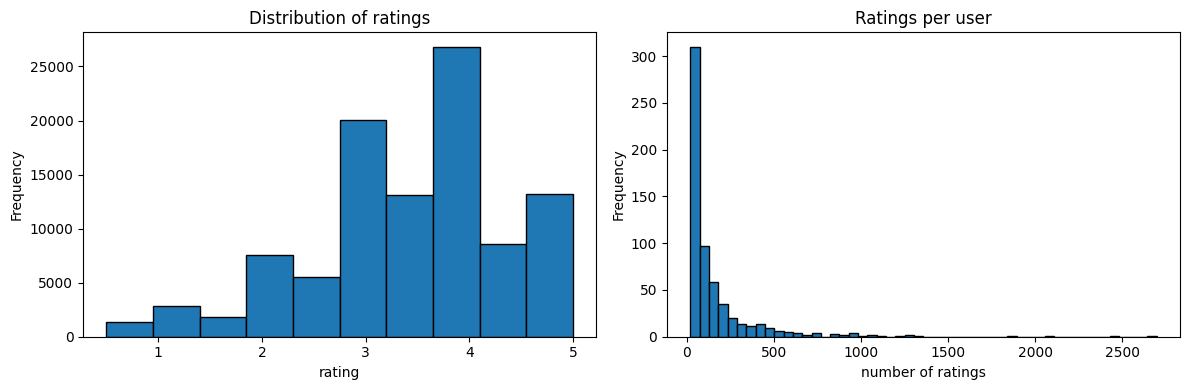

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ratings['rating'].plot(kind='hist', bins=10, ax=axes[0], edgecolor='black')
axes[0].set_title('Distribution of ratings')
axes[0].set_xlabel('rating')

ratings.groupby('userId').size().plot(kind='hist', bins=50, ax=axes[1], edgecolor='black')
axes[1].set_title('Ratings per user')
axes[1].set_xlabel('number of ratings')

plt.tight_layout()
plt.show()

In [6]:
movie_stats = (
    ratings.groupby('movieId')['rating']
           .agg(['count', 'mean'])
           .merge(movies, on='movieId')
)

print('Top 10 most rated movies:')
print(movie_stats.sort_values('count', ascending=False).head(10)[['title', 'count', 'mean']])

print('\nTop 10 best rated movies (>= 50 ratings):')
print(movie_stats[movie_stats['count'] >= 50]
      .sort_values('mean', ascending=False)
      .head(10)[['title', 'count', 'mean']])

Top 10 most rated movies:
                                          title  count      mean
314                         Forrest Gump (1994)    329  4.164134
277            Shawshank Redemption, The (1994)    317  4.429022
257                         Pulp Fiction (1994)    307  4.197068
510            Silence of the Lambs, The (1991)    279  4.161290
1938                         Matrix, The (1999)    278  4.192446
224   Star Wars: Episode IV - A New Hope (1977)    251  4.231076
418                        Jurassic Park (1993)    238  3.750000
97                            Braveheart (1995)    237  4.031646
507           Terminator 2: Judgment Day (1991)    224  3.970982
461                     Schindler's List (1993)    220  4.225000

Top 10 best rated movies (>= 50 ratings):
                                                                            title  \
277                                              Shawshank Redemption, The (1994)   
659                                           

## 3. Build the user × movie rating matrix

Each row is a user, each column is a movie, each cell is the rating that user gave to
that movie (or `NaN` / `0` if they have not rated it).

The matrix is **very sparse**: most users have rated a few hundred movies out of ~9000.

In [7]:
R_df = ratings.pivot(index='userId', columns='movieId', values='rating').fillna(0)
print(f'User-Movie matrix: {R_df.shape}')

sparsity = (R_df == 0).sum().sum() / (R_df.shape[0] * R_df.shape[1])
print(f'Sparsity: {sparsity:.2%}')
R_df.iloc[:5, :10]

User-Movie matrix: (610, 9724)
Sparsity: 98.30%


movieId,1,2,3,4,5,6,7,8,9,10
userId,,,,,,,,,,
1,4.0,0.0,4.0,0.0,0.0,4.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## 4. Matrix factorization with Truncated SVD

The rating matrix $R$ (users × movies) is factorized as

$$R \approx U \cdot \Sigma \cdot V^{\top}$$

where

- $U$ (users × k) places each **user** in a k-dimensional *latent taste space*
- $V$ (movies × k) places each **movie** in the same space
- $\Sigma$ holds the singular values (importance of each latent factor)

We keep only `k = 50` latent factors — this is the **compression** that lets the
model generalize to unseen (user, movie) pairs.

In [8]:
K = 50

R = R_df.values.astype(np.float32)
R_sparse = csr_matrix(R)

svd = TruncatedSVD(n_components=K, random_state=42)
U_sigma = svd.fit_transform(R_sparse)      # user factors * sigma  (n_users, k)
Vt      = svd.components_                  # item factors          (k, n_items)

print(f'User factors: {U_sigma.shape}')
print(f'Item factors: {Vt.shape}')
print(f'Explained variance (first {K} factors): {svd.explained_variance_ratio_.sum():.2%}')

User factors: (610, 50)
Item factors: (50, 9724)
Explained variance (first 50 factors): 53.88%


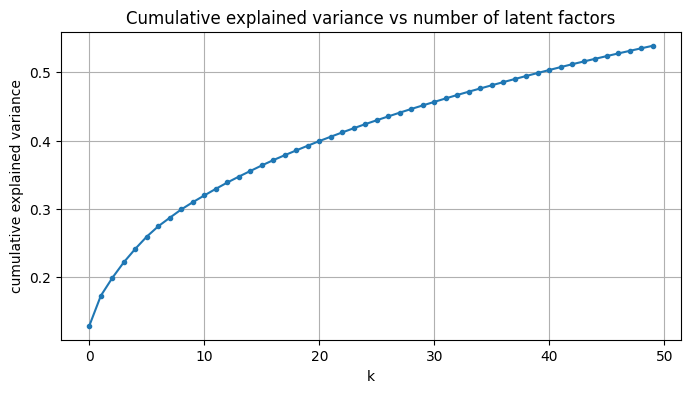

In [9]:
plt.figure(figsize=(8, 4))
plt.plot(np.cumsum(svd.explained_variance_ratio_), marker='o', markersize=3)
plt.title('Cumulative explained variance vs number of latent factors')
plt.xlabel('k')
plt.ylabel('cumulative explained variance')
plt.grid(True)
plt.show()

## 5. Reconstruct the full ratings matrix

Multiplying the two factors back gives a **dense** predicted ratings matrix:
even for (user, movie) pairs that were `0` in the original data,
the model now outputs a predicted score.

In [10]:
R_pred = U_sigma @ Vt    # (n_users, n_items)

pred_df = pd.DataFrame(R_pred, index=R_df.index, columns=R_df.columns)
print(f'Predicted ratings matrix: {pred_df.shape}')
pred_df.iloc[:5, :5]

Predicted ratings matrix: (610, 9724)


movieId,1,2,3,4,5
userId,,,,,
1,2.488744,1.078779,0.691686,-0.089449,-0.512702
2,0.275285,-0.082767,0.042566,0.005604,0.176293
3,0.031529,0.022221,0.041350,-0.000946,-0.016704
4,1.802801,-0.062078,-0.281749,0.082026,0.010910
5,1.404627,0.794783,0.037010,0.108644,0.266105


## 6. Recommend movies for a given user

For a target user:

1. Take the predicted ratings row.
2. **Mask out** movies the user has already rated (we only recommend unseen movies).
3. Return the top-N movies with the highest predicted score.

In [11]:
def recommend_for_user(user_id, n=10):
    if user_id not in R_df.index:
        raise ValueError(f'user {user_id} not found')

    user_ratings = R_df.loc[user_id]
    user_preds   = pred_df.loc[user_id]

    unseen = user_preds[user_ratings == 0]
    top = unseen.sort_values(ascending=False).head(n)

    out = pd.DataFrame({'movieId': top.index, 'predicted_rating': top.values})
    return out.merge(movies, on='movieId')[['movieId', 'title', 'genres', 'predicted_rating']]

USER = 1
print(f'--- Movies user {USER} already loved (rating >= 4.5) ---')
liked = (
    ratings[(ratings.userId == USER) & (ratings.rating >= 4.5)]
    .merge(movies, on='movieId')
    [['title', 'genres', 'rating']]
    .sort_values('rating', ascending=False)
    .head(10)
)
print(liked.to_string(index=False))

print(f'\n--- Top 10 recommendations for user {USER} ---')
recs = recommend_for_user(USER, n=10)
print(recs.to_string(index=False))

--- Movies user 1 already loved (rating >= 4.5) ---
                                   title                 genres  rating
             Seven (a.k.a. Se7en) (1995)       Mystery|Thriller     5.0
                  Very Bad Things (1998)           Comedy|Crime     5.0
        Run Lola Run (Lola rennt) (1998)           Action|Crime     5.0
                    Wolf Man, The (1941)   Drama|Fantasy|Horror     5.0
                      Superman II (1980)          Action|Sci-Fi     5.0
                        SLC Punk! (1998)           Comedy|Drama     5.0
                               Go (1999)           Comedy|Crime     5.0
                      Matrix, The (1999) Action|Sci-Fi|Thriller     5.0
Lock, Stock & Two Smoking Barrels (1998)  Comedy|Crime|Thriller     5.0
               Planet of the Apes (1968)    Action|Drama|Sci-Fi     5.0

--- Top 10 recommendations for user 1 ---
 movieId                             title                         genres  predicted_rating
    1036             

## 7. Item-item similarity: "Movies like this one"

Every column of `Vt` is a vector representing a movie in the latent space.
Two movies whose vectors point in the same direction are movies that tend to be
**rated similarly by the same users** — that is the very definition of *"similar movie"*
in collaborative filtering.

We compute cosine similarity between movie vectors and return the top-N most similar.

In [12]:
item_factors = Vt.T                            # (n_items, k)
item_sim = cosine_similarity(item_factors)     # (n_items, n_items)

movie_ids  = R_df.columns.to_numpy()
id_to_idx  = {mid: i for i, mid in enumerate(movie_ids)}

def similar_movies(title_query, n=10):
    matches = movies[movies['title'].str.contains(title_query, case=False, regex=False)]
    if matches.empty:
        raise ValueError(f'no movie matches "{title_query}"')

    movie_id = matches.iloc[0]['movieId']
    if movie_id not in id_to_idx:
        raise ValueError(f'"{matches.iloc[0].title}" has no ratings in the dataset')

    idx  = id_to_idx[movie_id]
    sims = item_sim[idx]
    top_idx = np.argsort(-sims)[1:n + 1]       # skip itself
    top_ids = movie_ids[top_idx]

    result = movies[movies['movieId'].isin(top_ids)].copy()
    result['similarity'] = result['movieId'].map(dict(zip(top_ids, sims[top_idx])))
    return (
        result.sort_values('similarity', ascending=False)
              [['title', 'genres', 'similarity']]
              .reset_index(drop=True)
    )

print('--- Movies similar to "Toy Story" ---')
print(similar_movies('Toy Story').to_string(index=False))

print('\n--- Movies similar to "Pulp Fiction" ---')
print(similar_movies('Pulp Fiction').to_string(index=False))

print('\n--- Movies similar to "Matrix" ---')
print(similar_movies('Matrix,').to_string(index=False))

--- Movies similar to "Toy Story" ---
                                          title                                      genres  similarity
Once Upon a Time... When We Were Colored (1995)                               Drama|Romance    0.572608
                                   Eddie (1996)                                      Comedy    0.562000
                             Toy Story 2 (1999) Adventure|Animation|Children|Comedy|Fantasy    0.558702
  Children of the Corn IV: The Gathering (1996)                                      Horror    0.555820
      Thin Line Between Love and Hate, A (1996)                                      Comedy    0.545709
                                Dear God (1996)                                      Comedy    0.544419
            Adventures of Pinocchio, The (1996)                          Adventure|Children    0.532236
                Cry, the Beloved Country (1995)                                       Drama    0.526563
                          

## 8. Evaluate reconstruction quality on known ratings

As a sanity check we compute the RMSE between the **real ratings** and the
**predicted ratings** on the cells that were actually rated. This is *not* a
proper train/test evaluation (the model has seen all ratings) but it tells us
how well the low-rank approximation fits the observed data.

In [13]:
mask = R != 0
rmse = np.sqrt(((R[mask] - R_pred[mask]) ** 2).mean())
mae  = np.abs(R[mask] - R_pred[mask]).mean()

print(f'RMSE on observed ratings: {rmse:.3f}')
print(f'MAE  on observed ratings: {mae:.3f}')

RMSE on observed ratings: 1.998
MAE  on observed ratings: 1.539


## Wrap-up

- We built a **collaborative filtering** recommender from scratch with only the
  user × movie rating matrix.
- **Truncated SVD** compressed that huge sparse matrix into a small set of
  latent factors that we can interpret as *tastes* and *movie characters*.
- The same latent space gave us two different recommendation modes:
  *top-N for a user* and *similar movies to a given movie*.

Typical next steps in a production recommender would be:

- Proper train/test split and hyper-parameter tuning (`k`).
- Use a library like [Surprise](https://surpriselib.com) or [implicit](https://implicit.readthedocs.io) that handles the "missing ≠ 0" issue more gracefully (centered SVD, ALS, BPR, ...).
- Combine collaborative filtering with **content-based** features (genres, tags) for a hybrid recommender that handles cold-start users and movies.